<a href="https://colab.research.google.com/github/Rihabd06/portfolio-site/blob/main/Liver_CT_Medical_Image_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q gdown tqdm matplotlib Pillow torchvision torchmetrics

In [ ]:
# Making sure that I'm working on a GPU to make training quicker
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [ ]:
# Unzipping the Dataset zip file
!unzip -q /content/Liver_Medical_Image_Datasets.zip
!ls -la "/content/Liver_Medical_Image _Datasets"
!ls -la "/content/Liver_Medical_Image _Datasets/Images" | head -20
!ls -la "/content/Liver_Medical_Image _Datasets/Labels" | head -20

replace Liver_Medical_Image _Datasets/Images/000.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
total 32
drwxr-xr-x 4 root root  4096 Oct  3  2024 .
drwxr-xr-x 1 root root  4096 Nov 27 12:24 ..
drwxr-xr-x 2 root root 12288 Nov 27 12:51 Images
drwxr-xr-x 2 root root 12288 Nov 27 12:51 Labels
total 65252
drwxr-xr-x 2 root root  12288 Nov 27 12:51 .
drwxr-xr-x 4 root root   4096 Oct  3  2024 ..
-rw-r--r-- 1 root root 158909 Dec  9  2019 000.png
-rw-r--r-- 1 root root 159362 Dec  9  2019 001.png
-rw-r--r-- 1 root root 158465 Dec  9  2019 002.png
-rw-r--r-- 1 root root 158204 Dec  9  2019 003.png
-rw-r--r-- 1 root root 158298 Dec  9  2019 004.png
-rw-r--r-- 1 root root 157945 Dec  9  2019 005.png
-rw-r--r-- 1 root root 158326 Dec  9  2019 006.png
-rw-r--r-- 1 root root 158848 Dec  9  2019 007.png
-rw-r--r-- 1 root root 159510 Dec  9  2019 008.png
-rw-r--r-- 1 root root 159599 Dec  9  2019 009.png
-rw-r--r-- 1 root root 159209 Dec  9  2019 010.png
-rw-r--r-- 1 root root 159531 Dec  9  2019 011

In [ ]:
import os, glob, random
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

IMAGES_DIR = "/content/Liver_Medical_Image _Datasets/Images"
LABELS_DIR = "/content/Liver_Medical_Image _Datasets/Labels"

#Sorting the images and labels and making sure that every image has a label
image_files = sorted(glob.glob(os.path.join(IMAGES_DIR, '*.png')))
mask_files  = sorted(glob.glob(os.path.join(LABELS_DIR, '*.png')))
assert len(image_files) == len(mask_files), "Images and masks counts differ!"

In [ ]:
#Spliting the dataset into training and validation sets(360 images for the training set and 40 for the validation set)
seed = 20
indices = list(range(len(image_files)))
random.seed(seed)
random.shuffle(indices)
train_idx = indices[:360]
val_idx   = indices[360:400]

train_images = [image_files[i] for i in train_idx]
train_masks  = [mask_files[i]  for i in train_idx]
val_images   = [image_files[i] for i in val_idx]
val_masks    = [mask_files[i]  for i in val_idx]

print("Train:", len(train_images), "Val:", len(val_images))

Train: 360 Val: 40


In [ ]:
#PyTorch Dataset and DataLoaders

class LiverDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform_size=(256,256), augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.size = transform_size
        self.augment = augment

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB').resize(self.size, Image.BILINEAR)
        msk = Image.open(self.mask_paths[idx]).convert('L').resize(self.size, Image.NEAREST)
        img = TF.to_tensor(img)
        msk = TF.to_tensor(msk)
        msk = (msk > 0.5).float()
        if self.augment and random.random() > 0.5:
            img = TF.hflip(img); msk = TF.hflip(msk)
        if self.augment and random.random() > 0.5:
            img = TF.vflip(img); msk = TF.vflip(msk)
        img = TF.normalize(img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        return img, msk

batch_size = 8 if torch.cuda.is_available() else 2
train_ds = LiverDataset(train_images, train_masks, transform_size=(256,256), augment=True)
val_ds = LiverDataset(val_images, val_masks, transform_size=(256,256), augment=False)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

imgs, msks = next(iter(train_loader))
print("Batch images shape:", imgs.shape, "masks shape:", msks.shape)

Batch images shape: torch.Size([8, 3, 256, 256]) masks shape: torch.Size([8, 1, 256, 256])


In [ ]:
#Create the U-Net model (Based on a research paper)
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64,128,256,512]):
        super().__init__()
        self.downs = nn.ModuleList()
        for f in features:
            self.downs.append(DoubleConv(in_ch, f))
            in_ch = f
        self.pool = nn.MaxPool2d(2,2)
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.up_trans = nn.ModuleList()
        self.up_conv = nn.ModuleList()
        for f in features[::-1]:
            self.up_trans.append(nn.ConvTranspose2d(f*2, f, 2, 2))
            self.up_conv.append(DoubleConv(f*2, f))
        self.final_conv = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(len(self.up_trans)):
            x = self.up_trans[i](x)
            skip = skips[i]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.up_conv[i](x)
        return self.final_conv(x)

model = UNet().to(device)
print("Model initialized on", device)

Model initialized on cuda


In [ ]:
#Setting up the loss functions, metrics, and optimizer

import torch.nn as nn
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6): super().__init__(); self.smooth = smooth
    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1); targets = targets.view(-1)
        inter = (inputs * targets).sum()
        dice = (2*inter + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 1 - dice

bce = nn.BCEWithLogitsLoss()
dice = DiceLoss()
def combined_loss(logits, targets, bce_w=0.5):
    return bce_w * bce(logits, targets) + (1 - bce_w) * dice(logits, targets)

def iou_and_pa(logits, targets, thresh=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    targets = (targets > 0.5).float()
    preds_f = preds.view(-1); targets_f = targets.view(-1)
    inter = (preds_f * targets_f).sum()
    union = preds_f.sum() + targets_f.sum() - inter
    iou = (inter + eps) / (union + eps)
    correct = (preds_f == targets_f).sum()
    pa = correct.float() / preds_f.numel()
    return iou.item(), pa.item()


import torch.optim as optim
lr = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


In [ ]:
#Training
from tqdm import tqdm
num_epochs = 20
best_val_loss = 1e9
train_losses, val_losses = [], []

scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} Train", leave=False)
    for imgs, msks in pbar:
        imgs = imgs.to(device); msks = msks.to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss = combined_loss(logits, msks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss = combined_loss(logits, msks)
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        pbar.set_postfix(loss=loss.item())
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

/tmp/ipython-input-2446461018.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
Epoch 1/20 Train:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipython-input-2446461018.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


In [ ]:
#Validation
model.eval()
val_loss_sum = 0.0
iou_sum = 0.0; pa_sum = 0.0; n_items = 0
with torch.no_grad():
    for imgs, msks in val_loader:
        imgs = imgs.to(device); msks = msks.to(device)
        logits = model(imgs)
        loss = combined_loss(logits, msks)
        val_loss_sum += loss.item() * imgs.size(0)
        iou, pa = iou_and_pa(logits, msks)
        iou_sum += iou * imgs.size(0)
        pa_sum += pa * imgs.size(0)
        n_items += imgs.size(0)
epoch_val_loss = val_loss_sum / len(val_loader.dataset)
val_losses.append(epoch_val_loss)
epoch_mIoU = iou_sum / n_items
epoch_mPA = pa_sum / n_items

print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f}, val_loss={epoch_val_loss:.4f}, mIoU={epoch_mIoU:.4f}, mPA={epoch_mPA:.4f}")
scheduler.step(epoch_val_loss)

Epoch 20: train_loss=0.1421, val_loss=0.1380, mIoU=0.9705, mPA=0.9974


In [ ]:
# Saving the best model
if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save({'epoch':epoch,'model_state':model.state_dict(),'optimizer':optimizer.state_dict()}, 'best_unet_liver.pth')
        print("Saved best_unet_liver.pth")

Saved best_unet_liver.pth


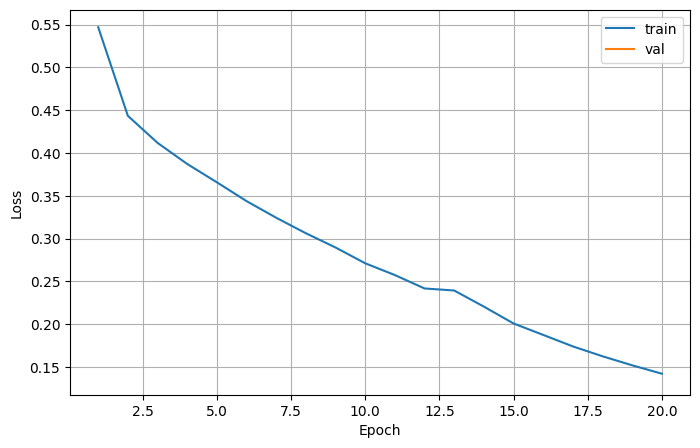

In [ ]:
#Plot

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1,len(train_losses)+1), train_losses, label='train')
plt.plot(range(1,len(val_losses)+1), val_losses, label='val')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.savefig("loss_curves.png", dpi=200)
plt.show()

In [ ]:
#Loading trained model and evaluating its performance
ckpt = torch.load('best_unet_liver.pth', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

total_iou=0.0; total_pa=0.0; count=0
with torch.no_grad():
    for imgs, msks in val_loader:
        imgs = imgs.to(device); msks = msks.to(device)
        logits = model(imgs)
        iou, pa = iou_and_pa(logits, msks)
        total_iou += iou * imgs.size(0)
        total_pa += pa * imgs.size(0)
        count += imgs.size(0)
dataset_mIoU = total_iou/count
dataset_mPA = total_pa/count
print(f"Validation mIoU: {dataset_mIoU:.4f}, mPA: {dataset_mPA:.4f}")

Validation mIoU: 0.9705, mPA: 0.9974


Saved predictions/example_0.png
Saved predictions/example_1.png
Saved predictions/example_2.png


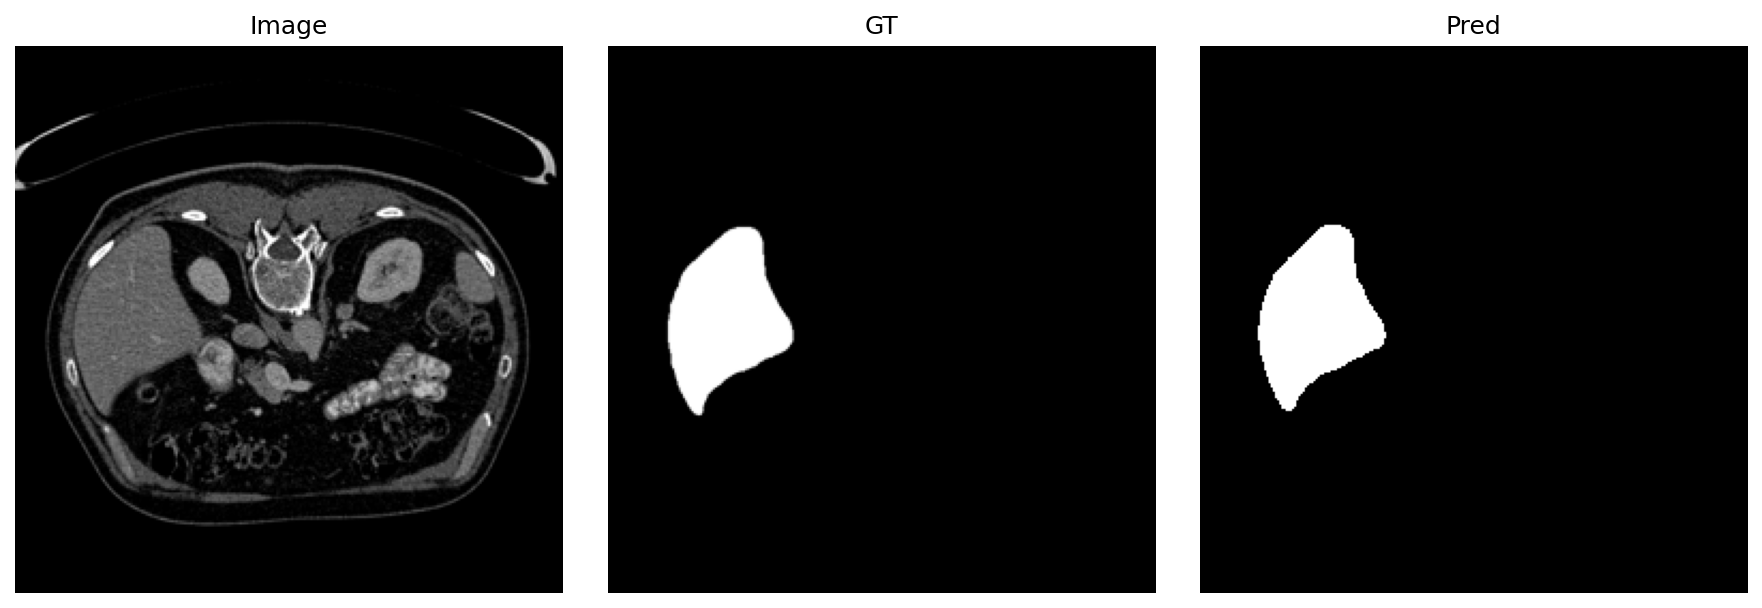

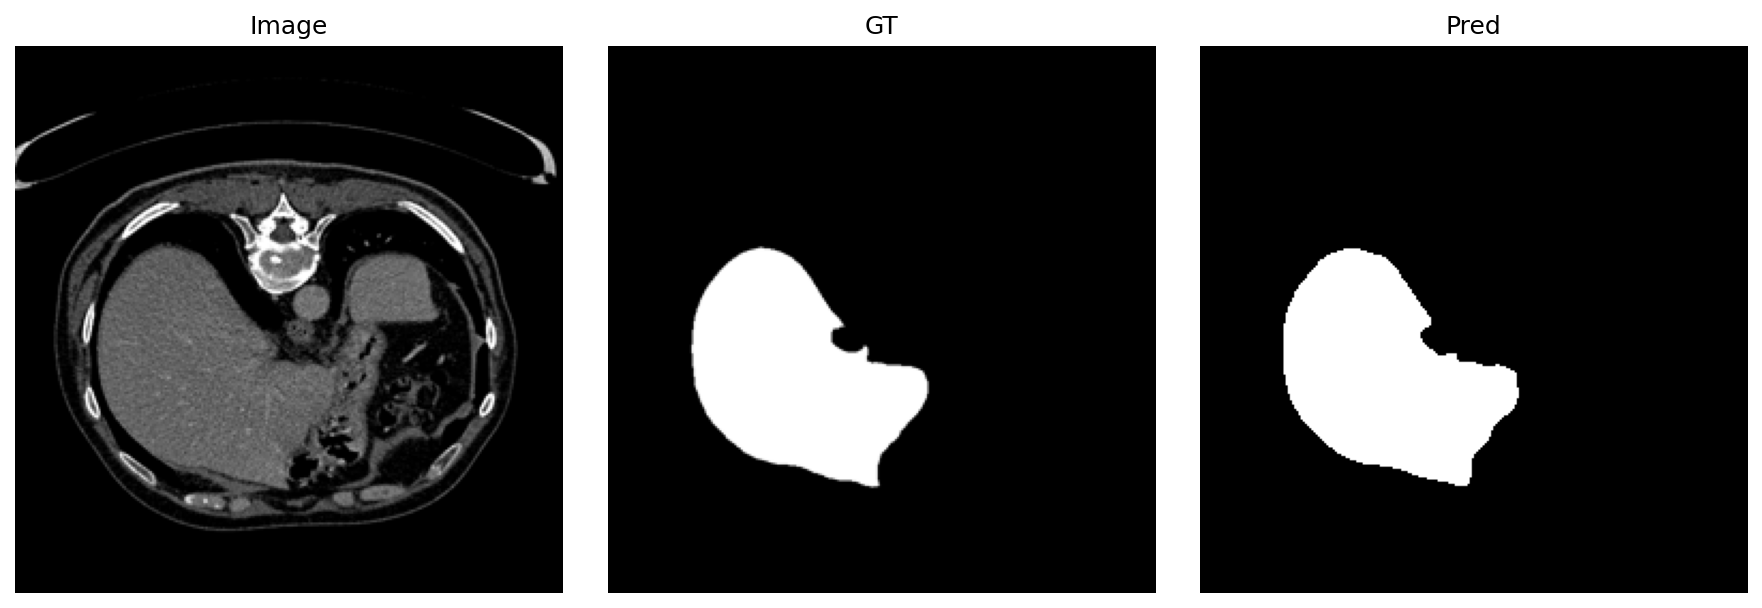

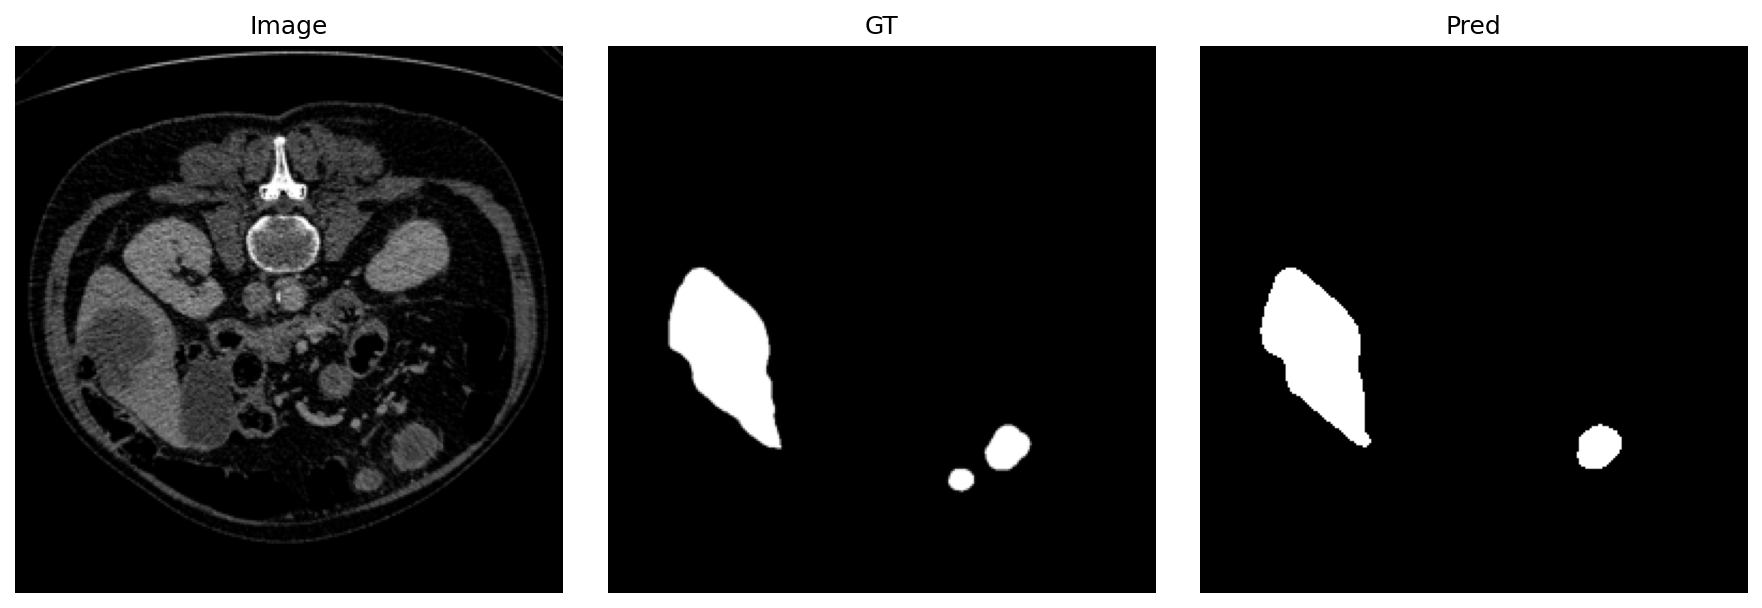

In [ ]:
#Single Image Segmentation
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
out_dir = Path("predictions"); out_dir.mkdir(exist_ok=True)

for i in range(min(3, len(val_images))):
    img_p = val_images[i]; mask_p = val_masks[i]
    img = Image.open(img_p).convert('RGB').resize((256,256))
    msk = Image.open(mask_p).convert('L').resize((256,256))
    t = TF.to_tensor(img); t = TF.normalize(t, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(t)
        prob = torch.sigmoid(logits)[0,0].cpu().numpy()
        pred = (prob > 0.5).astype(np.uint8)*255
    fig, ax = plt.subplots(1,3,figsize=(12,4))
    ax[0].imshow(img); ax[0].set_title("Image"); ax[0].axis('off')
    ax[1].imshow(msk, cmap='gray'); ax[1].set_title("GT"); ax[1].axis('off')
    ax[2].imshow(pred, cmap='gray'); ax[2].set_title("Pred"); ax[2].axis('off')
    plt.tight_layout()
    fp = out_dir / f"example_{i}.png"
    plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.close(fig)
    print("Saved", fp)

#Displaying Results
from IPython.display import display
from PIL import Image
img0 = Image.open("predictions/example_0.png")
display(img0)
img1 = Image.open("predictions/example_1.png")
display(img1)
img2 = Image.open("predictions/example_2.png")
display(img2)

Saved single_segmentation_result.png


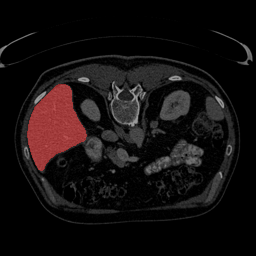

In [ ]:
#Single Image Segmentation
single = val_images[0]
img = Image.open(single).convert('RGB').resize((256,256))
t = TF.to_tensor(img); t = TF.normalize(t, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(t)
    prob = torch.sigmoid(logits)[0,0].cpu().numpy()
    pred = (prob > 0.5).astype(np.uint8)*255
overlay = np.array(img)
red = np.zeros_like(overlay); red[...,0] = pred
alpha = 0.4
combined = (overlay*(1-alpha) + red*alpha).astype(np.uint8)
from PIL import Image
Image.fromarray(combined).save("single_segmentation_result.png")
print("Saved single_segmentation_result.png")
single = Image.open("single_segmentation_result.png")
display(single)
